# Feature Correlation Analysis

This notebook computes feature-to-feature correlations from the final train dataset and saves reusable outputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE_DIR = Path.cwd()
if BASE_DIR.name != "HMW_feature_correlation_20260318":
    BASE_DIR = Path("ksm_note/HMW_feature_correlation_20260318")

DATA_PATH = BASE_DIR.parent / "data" / "ddri_prediction_canonical_train_2023_2024_multicollinearity_removed_v2.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/tj/Documents/GitHub/ddri_work/ksm_note/data/ddri_prediction_canonical_train_2023_2024_multicollinearity_removed_v2.csv')

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(2824584, 19)


,station_id,date,hour,rental_count,weekday,month,holiday,temperature,humidity,precipitation,wind_speed,cluster,bike_change_raw,bike_change_deseasonalized,bike_change_lag_1,bike_change_rollmean_24,bike_change_rollstd_24,bike_change_rollmean_168,bike_change_rollstd_168
0,2301,2023-01-01,0,0,6,1,1,-2.0,81,0.0,9.3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2301,2023-01-01,1,0,6,1,1,-1.7,82,0.0,9.3,2,0.0,0.603774,NaN,NaN,NaN,NaN,NaN
2,2301,2023-01-01,2,0,6,1,1,-0.8,77,0.0,10.8,2,0.0,0.150943,0.0,NaN,NaN,NaN,NaN
3,2301,2023-01-01,3,0,6,1,1,-1.8,83,0.0,8.0,2,0.0,0.075472,0.0,NaN,NaN,NaN,NaN
4,2301,2023-01-01,4,0,6,1,1,-4.0,90,0.0,8.6,2,0.0,0.113208,0.0,NaN,NaN,NaN,NaN


In [3]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
print("numeric feature count:", numeric_df.shape[1])
numeric_df.columns.tolist()

numeric feature count: 18


['station_id',
 'hour',
 'rental_count',
 'weekday',
 'month',
 'holiday',
 'temperature',
 'humidity',
 'precipitation',
 'wind_speed',
 'cluster',
 'bike_change_raw',
 'bike_change_deseasonalized',
 'bike_change_lag_1',
 'bike_change_rollmean_24',
 'bike_change_rollstd_24',
 'bike_change_rollmean_168',
 'bike_change_rollstd_168']

In [4]:
corr = numeric_df.corr(numeric_only=True)
corr

,station_id,hour,rental_count,weekday,month,holiday,temperature,humidity,precipitation,wind_speed,cluster,bike_change_raw,bike_change_deseasonalized,bike_change_lag_1,bike_change_rollmean_24,bike_change_rollstd_24,bike_change_rollmean_168,bike_change_rollstd_168
station_id,1.000000e+00,4.136285e-14,-0.076691,1.963079e-14,2.529737e-14,-6.662343e-15,-4.530718e-14,-6.801742e-14,2.631954e-15,8.219654e-14,-1.541981e-01,0.000001,1.860284e-06,-1.471135e-06,-0.000006,-0.156709,0.000234,-0.200201
hour,4.136285e-14,1.000000e+00,0.183602,-1.777655e-18,1.019485e-16,2.052029e-19,1.217539e-01,-2.573734e-01,7.863327e-03,1.632480e-01,-5.910447e-15,-0.029555,-2.259612e-03,-3.199802e-03,0.000061,0.002655,0.000046,-0.000013
rental_count,-7.669083e-02,1.836020e-01,1.000000,-5.013662e-02,3.872627e-02,-4.326859e-02,1.745765e-01,-1.271493e-01,-6.483168e-02,2.169600e-02,-3.361707e-02,0.531049,4.963469e-01,1.025257e-01,0.093193,0.336581,0.085342,0.355027
weekday,1.963079e-14,-1.777655e-18,-0.050137,1.000000e+00,9.509313e-03,-4.766507e-02,1.988102e-03,2.200142e-02,-5.666330e-03,2.711310e-03,1.527381e-15,-0.001281,-7.494579e-05,-2.544871e-03,-0.053580,-0.041778,-0.000171,0.000920
month,2.529737e-14,1.019485e-16,0.038726,9.509313e-03,1.000000e+00,-4.308035e-02,2.262259e-01,1.967700e-01,3.410106e-02,-9.889947e-02,-2.948308e-15,-0.000088,-7.626499e-05,-1.496240e-04,-0.003569,0.082726,-0.018087,0.113437
holiday,-6.662343e-15,2.052029e-19,-0.043269,-4.766507e-02,-4.308035e-02,1.000000e+00,-4.080711e-02,6.363866e-04,1.594897e-02,1.571392e-02,9.259160e-16,-0.000770,-8.876094e-04,-1.467124e-03,-0.029102,-0.049444,-0.042075,-0.020484
temperature,-4.530718e-14,1.217539e-01,0.174576,1.988102e-03,2.262259e-01,-4.080711e-02,1.000000e+00,1.588475e-01,1.341622e-01,1.622995e-02,6.565810e-15,0.003260,-4.236733e-04,5.302109e-03,-0.001035,0.261253,0.011375,0.307824
humidity,-6.801742e-14,-2.573734e-01,-0.127149,2.200142e-02,1.967700e-01,6.363866e-04,1.588475e-01,1.000000e+00,1.729101e-01,-2.533578e-01,1.724132e-14,-0.010046,1.031061e-03,-1.453115e-02,-0.031406,0.026492,-0.049497,0.072525
precipitation,2.631954e-15,7.863327e-03,-0.064832,-5.666330e-03,3.410106e-02,1.594897e-02,1.341622e-01,1.729101e-01,1.000000e+00,1.541047e-01,8.925080e-16,-0.001505,-1.405365e-03,-5.194833e-03,-0.068678,-0.031437,-0.074889,0.027766
wind_speed,8.219654e-14,1.632480e-01,0.021696,2.711310e-03,-9.889947e-02,1.571392e-02,1.622995e-02,-2.533578e-01,1.541047e-01,1.000000e+00,4.033984e-15,0.009670,1.646514e-04,1.142700e-02,-0.019102,-0.082020,-0.045009,-0.019737


In [5]:
corr_path = OUTPUT_DIR / "feature_correlation_matrix.csv"
corr.to_csv(corr_path, encoding="utf-8-sig")
corr_path

WindowsPath('c:/Users/tj/Documents/GitHub/ddri_work/ksm_note/HMW_feature_correlation_20260318/outputs/feature_correlation_matrix.csv')

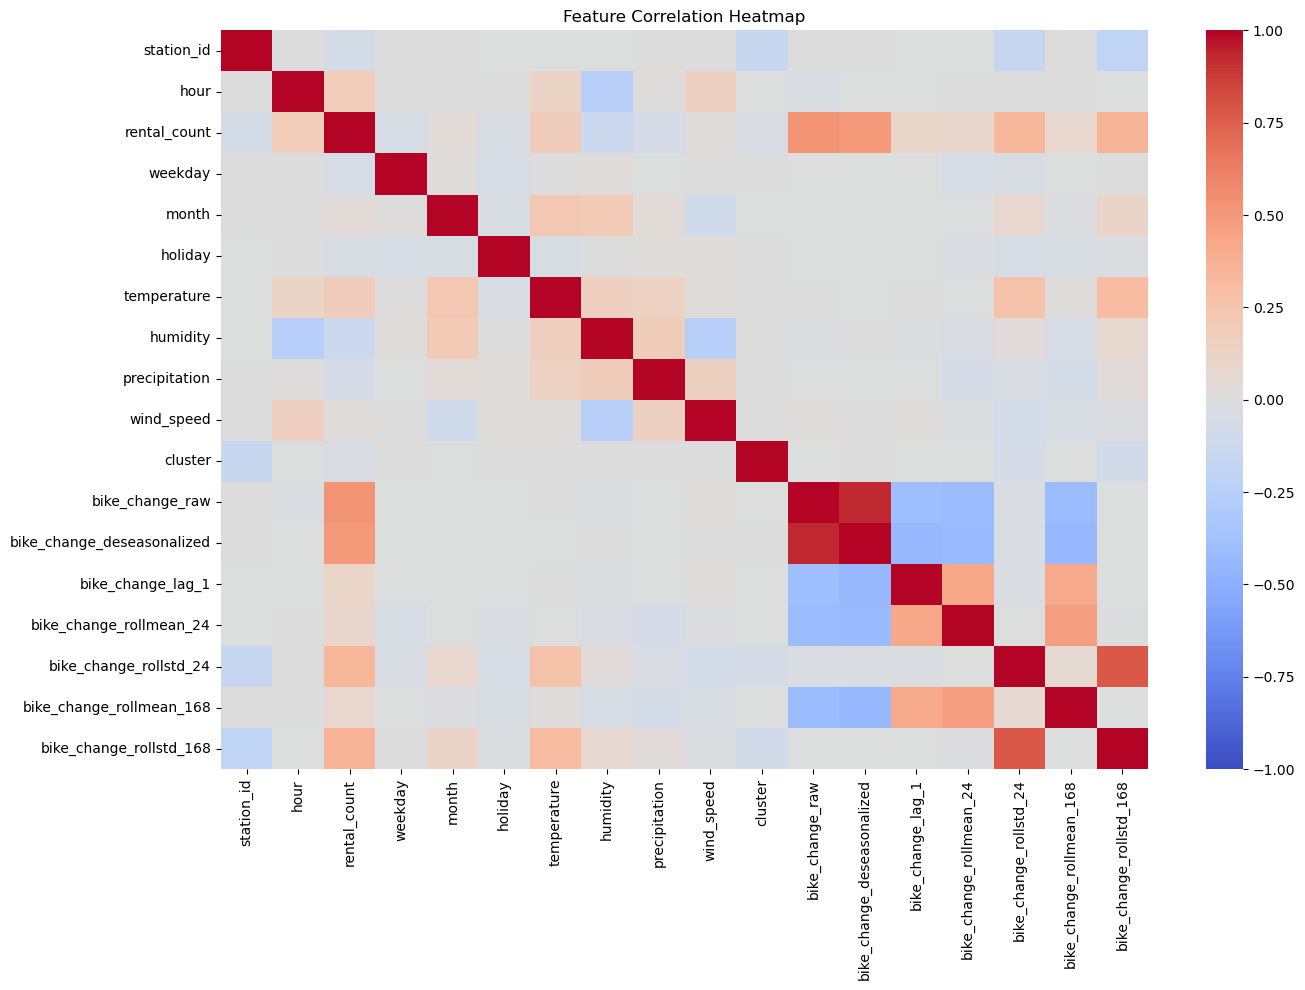

WindowsPath('c:/Users/tj/Documents/GitHub/ddri_work/ksm_note/HMW_feature_correlation_20260318/outputs/feature_correlation_heatmap.png')

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
heatmap_path = OUTPUT_DIR / "feature_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()
heatmap_path

In [7]:
threshold = 0.7
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ["feature_a", "feature_b", "correlation"]
pairs["abs_correlation"] = pairs["correlation"].abs()
high_corr_pairs = pairs[pairs["abs_correlation"] >= threshold].sort_values(
    "abs_correlation", ascending=False
)
high_corr_pairs.head(20)

,feature_a,feature_b,correlation,abs_correlation
132,bike_change_raw,bike_change_deseasonalized,0.934864,0.934864
151,bike_change_rollstd_24,bike_change_rollstd_168,0.777213,0.777213


In [8]:
high_corr_path = OUTPUT_DIR / "high_correlation_pairs_over_0_7.csv"
high_corr_pairs.to_csv(high_corr_path, index=False, encoding="utf-8-sig")
high_corr_path

WindowsPath('c:/Users/tj/Documents/GitHub/ddri_work/ksm_note/HMW_feature_correlation_20260318/outputs/high_correlation_pairs_over_0_7.csv')